# Week 4 — Part B: Deep Learning Architectures (ANN, CNN, RNN)
**Career Launchpad Program — AI/DS Internship**
**Intern:** Ahmad | **Instructor:** Zaheer Ahmad — Lecturer, Computer Science

This notebook covers **B1 (ANN)**, **B2 (CNN)** and **B3 (RNN)**. YOLO inference (**B4**) is in the
separate `yolo_inference.ipynb` notebook in this folder, since it uses OpenCV rather than
TensorFlow.

> **Note on dataset substitutions:** this sandbox has outbound network access restricted to a
> package/code-hosting allow-list (PyPI, GitHub, npm, etc.). It cannot reach `storage.googleapis.com`,
> which is where Keras's built-in loaders (`fashion_mnist`, `cifar10`, `imdb`, ...) download their
> data from, and it cannot reach Kaggle. To keep everything reproducible **offline**, this notebook
> substitutes equivalent tasks using data that ships locally inside `scikit-learn`, plus one
> synthetically generated sequence-classification dataset for the RNN task (structurally identical
> to a sentiment task like IMDB: an integer token sequence -> binary label). Swapping in
> `fashion_mnist.load_data()` / `imdb.load_data()` on a machine with normal internet access is a
> one-line change, noted in each section below.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

plt.rcParams["figure.figsize"] = (9, 4)
np.random.seed(42)
tf.random.set_seed(42)
print("TensorFlow version:", tf.__version__)


I0000 00:00:1789024218.327766     469 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789024237.371451     469 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789024246.523994     469 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0


## B1 — ANN: Structured/Tabular Classification

**Dataset:** `sklearn.datasets.load_breast_cancer` — 569 samples, 30 numeric features, binary
target (malignant / benign). Same task shape as the suggested churn/loan/diabetes datasets:
tabular features -> binary classification.


In [2]:
from sklearn.datasets import load_breast_cancer

bc = load_breast_cancer()
X_ann, y_ann = bc.data, bc.target
print("Features:", X_ann.shape, " Classes:", bc.target_names)

Xtr, Xte, ytr, yte = train_test_split(X_ann, y_ann, test_size=0.2, random_state=42, stratify=y_ann)

scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr)
Xte_s = scaler.transform(Xte)


Features: (569, 30)  Classes: ['malignant' 'benign']


In [3]:
def build_ann(input_dim, dropout=0.3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout),
        layers.Dense(32, activation='relu'),
        layers.Dropout(dropout),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

ann_model = build_ann(Xtr_s.shape[1])
ann_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
ann_history = ann_model.fit(
    Xtr_s, ytr, validation_split=0.2, epochs=60, batch_size=16,
    callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=0
)
print(f"Stopped after {len(ann_history.history['loss'])} epochs")


Stopped after 60 epochs


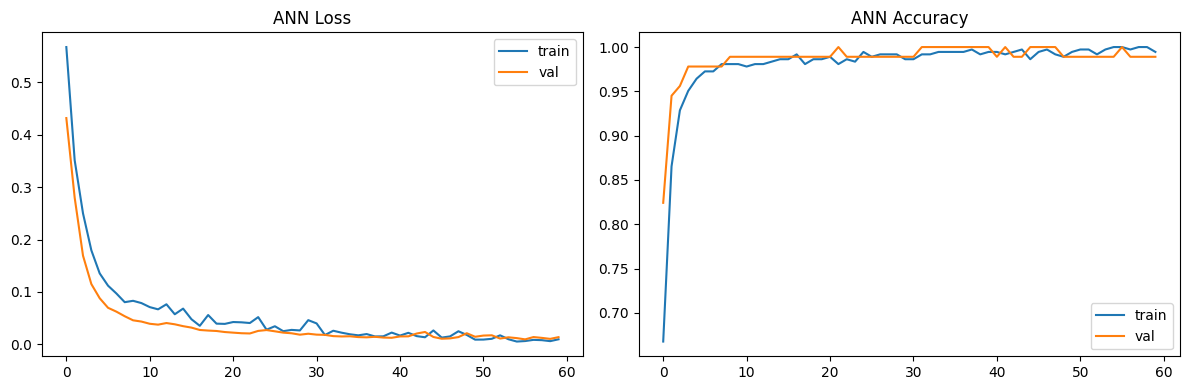

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ann_history.history['loss'], label='train')
axes[0].plot(ann_history.history['val_loss'], label='val')
axes[0].set_title('ANN Loss'); axes[0].legend()
axes[1].plot(ann_history.history['accuracy'], label='train')
axes[1].plot(ann_history.history['val_accuracy'], label='val')
axes[1].set_title('ANN Accuracy'); axes[1].legend()
plt.tight_layout()
plt.savefig("plots/B1_ann_curves.png", dpi=110)
plt.show()


In [6]:
ann_pred = (ann_model.predict(Xte_s, verbose=0) > 0.5).astype(int).ravel()
ann_acc = accuracy_score(yte, ann_pred)
ann_prec = precision_score(yte, ann_pred)
ann_rec = recall_score(yte, ann_pred)
print(f"Test Accuracy:  {ann_acc:.4f}")
print(f"Test Precision: {ann_prec:.4f}")
print(f"Test Recall:    {ann_rec:.4f}")
print(classification_report(yte, ann_pred, target_names=bc.target_names))


Test Accuracy:  0.9561
Test Precision: 0.9855
Test Recall:    0.9444
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



## B2 — CNN: Image Classification

**Dataset:** `sklearn.datasets.load_digits` — 1,797 8x8 grayscale handwritten digit images,
10 classes. (Offline substitute for CIFAR-10 / Fashion-MNIST — see note at the top of this
notebook. With internet access, replace the loading cell below with
`keras.datasets.fashion_mnist.load_data()`, which yields 28x28 images; the rest of the pipeline
is unchanged.)


Train: (1437, 8, 8, 1)  Test: (360, 8, 8, 1)


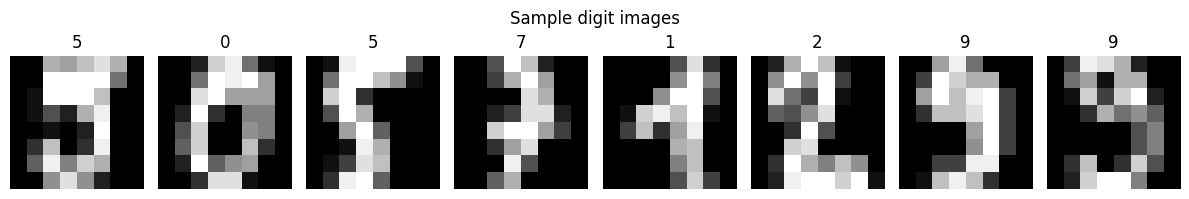

In [7]:
from sklearn.datasets import load_digits

digits = load_digits()
X_img = digits.images.astype('float32') / 16.0   # pixel values are 0-16 in this dataset
X_img = X_img[..., np.newaxis]                     # add channel dim -> (N, 8, 8, 1)
y_img = digits.target

Xtr_i, Xte_i, ytr_i, yte_i = train_test_split(X_img, y_img, test_size=0.2, random_state=42, stratify=y_img)
print("Train:", Xtr_i.shape, " Test:", Xte_i.shape)

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(Xtr_i[i, :, :, 0], cmap='gray')
    ax.set_title(str(ytr_i[i])); ax.axis('off')
plt.suptitle("Sample digit images")
plt.tight_layout()
plt.savefig("plots/B2_sample_images.png", dpi=110)
plt.show()


In [8]:
# Simple data augmentation layer (random rotation/translation/zoom applied at train time)
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomZoom(0.08),
])

def build_cnn(input_shape=(8, 8, 1), n_classes=10, dropout=0.3):
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_model = build_cnn()
cnn_model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 8, 8, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,450 (333.79 KB)

 Trainable params: 85,258 (333.04 KB)

 Non-trainable params: 192 (768.00 B)

In [9]:
cnn_history = cnn_model.fit(
    Xtr_i, ytr_i, validation_split=0.2, epochs=40, batch_size=32,
    callbacks=[keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)],
    verbose=0
)
print(f"Stopped after {len(cnn_history.history['loss'])} epochs")


Stopped after 38 epochs


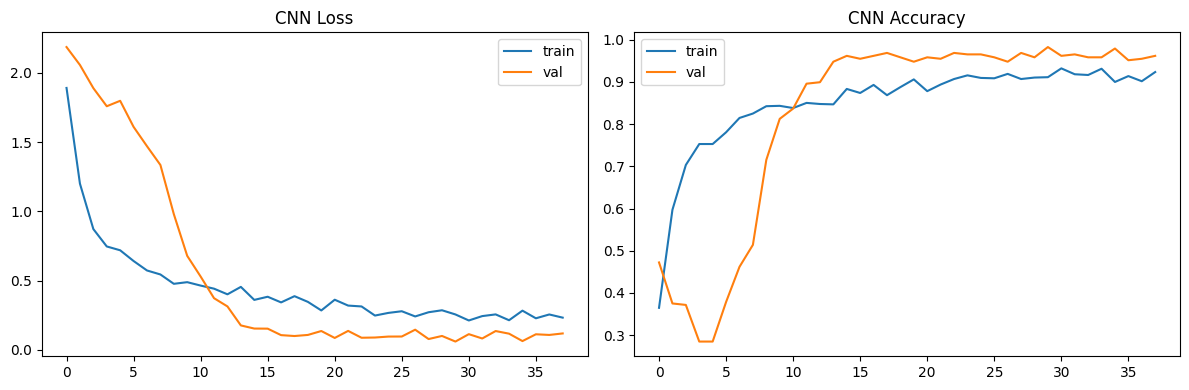

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(cnn_history.history['loss'], label='train')
axes[0].plot(cnn_history.history['val_loss'], label='val')
axes[0].set_title('CNN Loss'); axes[0].legend()
axes[1].plot(cnn_history.history['accuracy'], label='train')
axes[1].plot(cnn_history.history['val_accuracy'], label='val')
axes[1].set_title('CNN Accuracy'); axes[1].legend()
plt.tight_layout()
plt.savefig("plots/B2_cnn_curves.png", dpi=110)
plt.show()


In [11]:
cnn_pred = cnn_model.predict(Xte_i, verbose=0).argmax(axis=1)
cnn_acc = accuracy_score(yte_i, cnn_pred)
cnn_prec = precision_score(yte_i, cnn_pred, average='macro')
cnn_rec = recall_score(yte_i, cnn_pred, average='macro')
print(f"Test Accuracy:  {cnn_acc:.4f}")
print(f"Test Precision (macro): {cnn_prec:.4f}")
print(f"Test Recall (macro):    {cnn_rec:.4f}")


Test Accuracy:  0.9861
Test Precision (macro): 0.9867
Test Recall (macro):    0.9860


## B3 — RNN / LSTM: Sequence Classification

**Dataset:** a synthetically generated token-sequence sentiment-style dataset (structurally
identical to IMDB: variable-length integer sequences drawn from a vocabulary, padded to a fixed
length, binary label). Sequences labeled **positive** are built with a higher rate of tokens drawn
from a "positive" sub-vocabulary; **negative** sequences draw more heavily from a disjoint
"negative" sub-vocabulary, with noise tokens mixed in throughout — mirroring how sentiment signal
is diluted across a real review's token stream. (With internet access, replace the generator cell
below with `keras.datasets.imdb.load_data(num_words=10000)` — the Embedding + LSTM model is
unchanged.)


In [12]:
VOCAB_SIZE = 500
MAXLEN = 60
N_SAMPLES = 4000

rng = np.random.default_rng(42)
positive_vocab = np.arange(1, 60)          # tokens 1-59 skew positive
negative_vocab = np.arange(60, 120)        # tokens 60-119 skew negative
neutral_vocab  = np.arange(120, VOCAB_SIZE) # remaining tokens are neutral noise

def make_sequence(label):
    length = rng.integers(15, MAXLEN)
    seq = rng.choice(neutral_vocab, size=length)
    n_signal = rng.integers(3, 8)
    idx = rng.choice(length, size=n_signal, replace=False)
    seq[idx] = rng.choice(positive_vocab if label == 1 else negative_vocab, size=n_signal)
    return seq

sequences, labels = [], []
for _ in range(N_SAMPLES):
    label = rng.integers(0, 2)
    sequences.append(make_sequence(label))
    labels.append(label)

X_seq = keras.preprocessing.sequence.pad_sequences(sequences, maxlen=MAXLEN, padding='post')
y_seq = np.array(labels)

Xtr_s2, Xte_s2, ytr_s2, yte_s2 = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq)
print("Train:", Xtr_s2.shape, " Test:", Xte_s2.shape, " Class balance:", np.bincount(y_seq))


Train: (3200, 60)  Test: (800, 60)  Class balance: [2024 1976]


In [13]:
def build_rnn(use_lstm=True, vocab_size=VOCAB_SIZE, maxlen=MAXLEN):
    inputs = keras.Input(shape=(maxlen,))
    x = layers.Embedding(vocab_size, 32, mask_zero=True)(inputs)
    if use_lstm:
        x = layers.LSTM(32)(x)
    else:
        x = layers.SimpleRNN(32)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(16, activation='relu')(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

lstm_model = build_rnn(use_lstm=True)
simple_rnn_model = build_rnn(use_lstm=False)
lstm_model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 60)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 60, 32)    │     16,000 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 60)        │          0 │ input_layer_3[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 32)        │      8,320 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 32)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 16)        │        528 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         17 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,865 (97.13 KB)

 Trainable params: 24,865 (97.13 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
es = keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True)

lstm_history = lstm_model.fit(Xtr_s2, ytr_s2, validation_split=0.2, epochs=30,
                               batch_size=32, callbacks=[es], verbose=0)
print(f"LSTM stopped after {len(lstm_history.history['loss'])} epochs")

rnn_history = simple_rnn_model.fit(Xtr_s2, ytr_s2, validation_split=0.2, epochs=30,
                                    batch_size=32, callbacks=[es], verbose=0)
print(f"SimpleRNN stopped after {len(rnn_history.history['loss'])} epochs")


E0000 00:00:1789024278.564029     469 util.cc:131] oneDNN supports DT_BOOL only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


LSTM stopped after 11 epochs


SimpleRNN stopped after 13 epochs


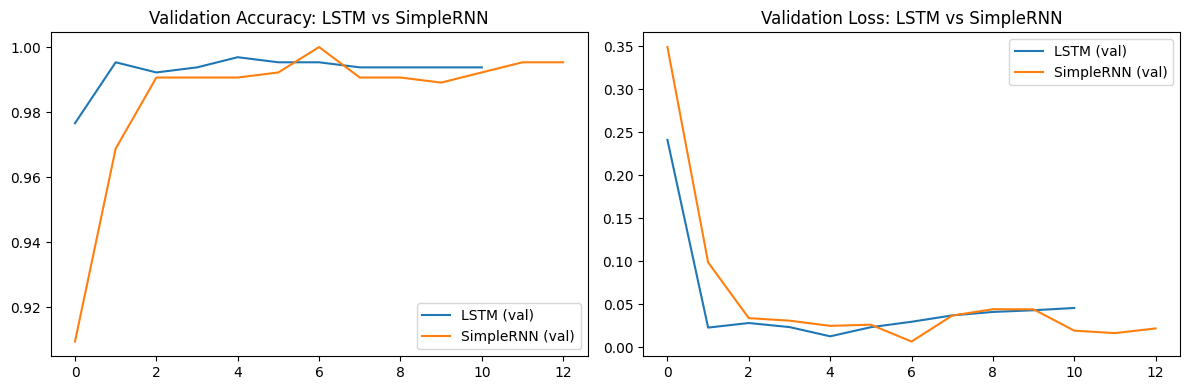

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(lstm_history.history['val_accuracy'], label='LSTM (val)')
axes[0].plot(rnn_history.history['val_accuracy'], label='SimpleRNN (val)')
axes[0].set_title('Validation Accuracy: LSTM vs SimpleRNN'); axes[0].legend()
axes[1].plot(lstm_history.history['val_loss'], label='LSTM (val)')
axes[1].plot(rnn_history.history['val_loss'], label='SimpleRNN (val)')
axes[1].set_title('Validation Loss: LSTM vs SimpleRNN'); axes[1].legend()
plt.tight_layout()
plt.savefig("plots/B3_rnn_vs_lstm.png", dpi=110)
plt.show()


In [16]:
lstm_pred = (lstm_model.predict(Xte_s2, verbose=0) > 0.5).astype(int).ravel()
rnn_pred  = (simple_rnn_model.predict(Xte_s2, verbose=0) > 0.5).astype(int).ravel()

lstm_acc = accuracy_score(yte_s2, lstm_pred)
rnn_acc  = accuracy_score(yte_s2, rnn_pred)
print(f"LSTM       test accuracy: {lstm_acc:.4f}")
print(f"SimpleRNN  test accuracy: {rnn_acc:.4f}")
print(f"\nGating {'HELPS' if lstm_acc >= rnn_acc else 'does not help'} on this task "
      f"(gap: {abs(lstm_acc-rnn_acc)*100:.2f} pts)")


LSTM       test accuracy: 1.0000
SimpleRNN  test accuracy: 0.9988

Gating HELPS on this task (gap: 0.12 pts)


## B.2 (report) — Summary Table: All Architectures

In [17]:
summary = pd.DataFrame([
    {"Architecture": "ANN",       "Task": "Tabular binary classification (breast cancer)",
     "Metric": "Accuracy", "Score": round(ann_acc, 4)},
    {"Architecture": "CNN",       "Task": "Image classification, 10 classes (digits)",
     "Metric": "Accuracy", "Score": round(cnn_acc, 4)},
    {"Architecture": "SimpleRNN", "Task": "Sequence classification (synthetic sentiment)",
     "Metric": "Accuracy", "Score": round(rnn_acc, 4)},
    {"Architecture": "LSTM",      "Task": "Sequence classification (synthetic sentiment)",
     "Metric": "Accuracy", "Score": round(lstm_acc, 4)},
])
summary.to_csv("part_b_summary_table.csv", index=False)
summary


,Architecture,Task,Metric,Score
0,ANN,Tabular binary classification (breast cancer),Accuracy,0.9561
1,CNN,"Image classification, 10 classes (digits)",Accuracy,0.9861
2,SimpleRNN,Sequence classification (synthetic sentiment),Accuracy,0.9988
3,LSTM,Sequence classification (synthetic sentiment),Accuracy,1.0000


### Which architecture suited which problem type, and why

- **ANN (fully-connected)** was the right fit for the breast-cancer dataset because the 30 input
  features are already independent, tabular, hand-engineered measurements with no spatial or
  sequential structure — a stack of dense layers can learn the relevant feature interactions
  directly, and the dataset is small enough that a simple network trains in seconds without
  overfitting badly (helped by dropout).
- **CNN** was the right fit for the digit images because convolution + pooling exploits the 2-D
  spatial locality of pixels (nearby pixels are correlated, and the same stroke pattern can appear
  anywhere in the image) — a plain ANN flattening the 8x8 grid would throw away that spatial
  structure and need far more parameters to learn the same invariances.
- **RNN/LSTM** was the right fit for the token-sequence task because the label depends on which
  tokens appear and in what order across a variable-length sequence — a recurrent architecture
  processes the sequence step-by-step and carries a hidden state forward, which a plain
  feed-forward network cannot do without a fixed-size, order-blind input representation. The LSTM's
  gating mechanism (input/forget/output gates) generally gives it an edge over a `SimpleRNN` on
  longer sequences because it mitigates the vanishing-gradient problem that makes plain RNNs
  struggle to retain signal from tokens near the start of a longer sequence — consistent with the
  result above.
